https://www.kaggle.com/datasets/sanjanchaudhari/employees-performance-for-hr-analytics

In [ ]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [ ]:
# Import the 'drive' module from 'google.colab' which allows Colab to access Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# We define the file path to the CSV dataset stored in Google Drive
file_path = '/content/drive/MyDrive/datasets/hr_data.csv'

# We read the CSV file from the specified path into a pandas DataFrame called 'hr_data'
hr_data = pd.read_csv(file_path)

In [ ]:
# explore hr_data structure
hr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [ ]:
# check duplicated rows
hr_data.duplicated().sum()

np.int64(2)

In [ ]:
# inspect duplicated rows
duplicates = hr_data[hr_data.duplicated()]
print(duplicates)

       employee_id department    region  education gender recruitment_channel  \
17414        49584         HR  region_7  Bachelors      m               other   
17415        49584         HR  region_7  Bachelors      m               other   

       no_of_trainings  age  previous_year_rating  length_of_service  \
17414                1   33                   1.0                  9   
17415                1   33                   1.0                  9   

       KPIs_met_more_than_80  awards_won  avg_training_score  
17414                      0           0                  51  
17415                      0           0                  51  


In [ ]:
# drop duplicated rows
hr_data= hr_data.drop_duplicates()

In [ ]:
# check percentages of missing values
hr_data.isna().mean()*100

# we have two columns with missing values: education and previous_year_rating

,0
employee_id,0.000000
department,0.000000
region,0.000000
education,4.427218
gender,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
previous_year_rating,7.826586
length_of_service,0.000000


In [ ]:
# check unique values of 'education'
hr_data['education'].unique()

array(['Bachelors', 'Masters & above', nan, 'Below Secondary'],
      dtype=object)

In [ ]:
# check the frequency of each value in education
hr_data['education'].value_counts(dropna=False)

# fillna with 'Unknown'
# better change datatype into category

,count
education,
Bachelors,11517
Masters & above,4841
NaN,771
Below Secondary,286


In [ ]:
# fill education's missing values with 'Unknown'
hr_data['education'] = hr_data['education'].fillna('Unknown').astype('category')

In [ ]:
# check if education is filled with 'Unknown'
hr_data['education'].isna().sum()

np.int64(0)

In [ ]:
# check unique values of previous_year_rating column
hr_data['previous_year_rating'].unique()

# we fill missing values with median
# change data type into integer

array([nan,  3.,  1.,  2.,  4.,  5.])

In [ ]:
hr_data['previous_year_rating'] = (hr_data['previous_year_rating']
                                   .fillna(hr_data['previous_year_rating']
                                           .median())
                                   .astype(int)
)


In [ ]:
# check if education is filled with 'Unknown'
hr_data['previous_year_rating'].isna().sum()

np.int64(0)

In [ ]:
# check the dataset structure again
hr_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17415 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   employee_id            17415 non-null  int64   
 1   department             17415 non-null  object  
 2   region                 17415 non-null  object  
 3   education              17415 non-null  category
 4   gender                 17415 non-null  object  
 5   recruitment_channel    17415 non-null  object  
 6   no_of_trainings        17415 non-null  int64   
 7   age                    17415 non-null  int64   
 8   previous_year_rating   17415 non-null  int64   
 9   length_of_service      17415 non-null  int64   
 10  KPIs_met_more_than_80  17415 non-null  int64   
 11  awards_won             17415 non-null  int64   
 12  avg_training_score     17415 non-null  int64   
dtypes: category(1), int64(8), object(4)
memory usage: 1.7+ MB


In [ ]:
# check statistics for all columns
hr_data.describe(include='all')

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17415.000000,17415,17415,17415,17415,17415,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000
unique,NaN,9,34,4,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Sales & Marketing,region_2,Bachelors,m,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5458,3918,11517,12312,9749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39082.285214,NaN,NaN,NaN,NaN,NaN,1.250761,34.807982,3.318691,5.801493,0.358886,0.023371,63.177720
std,22708.049139,NaN,NaN,NaN,NaN,NaN,0.595720,7.694464,1.218216,4.175632,0.479687,0.151082,13.418314
min,3.000000,NaN,NaN,NaN,NaN,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19280.500000,NaN,NaN,NaN,NaN,NaN,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39115.000000,NaN,NaN,NaN,NaN,NaN,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.500000,NaN,NaN,NaN,NaN,NaN,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000


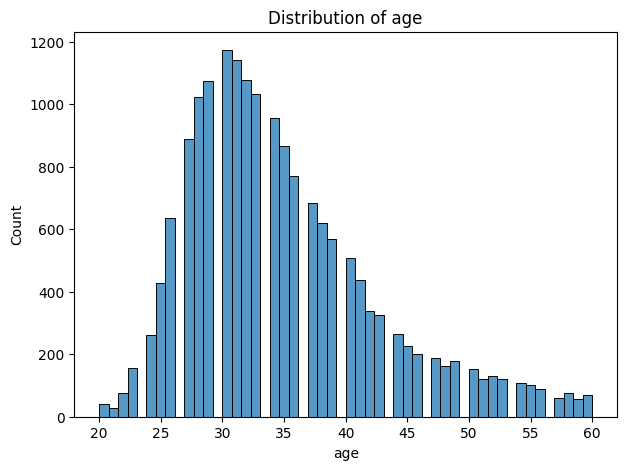

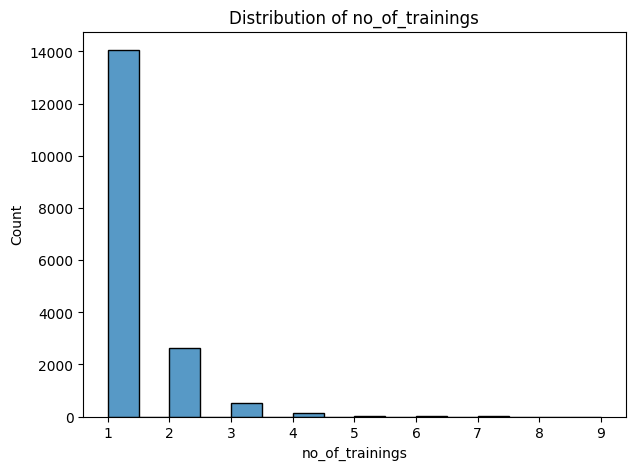

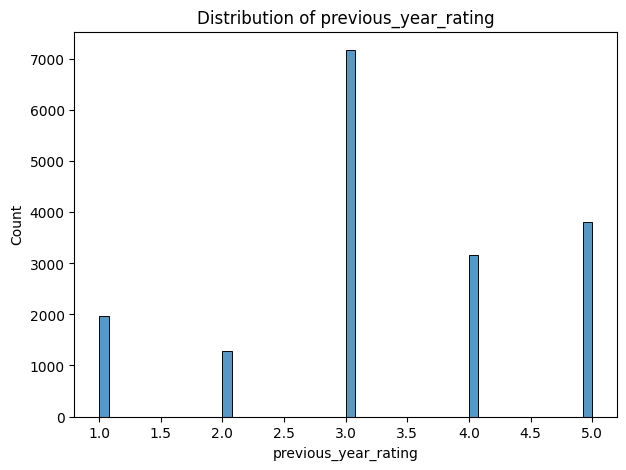

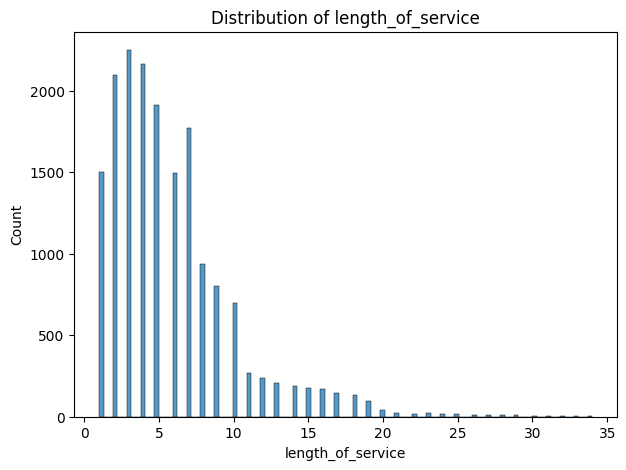

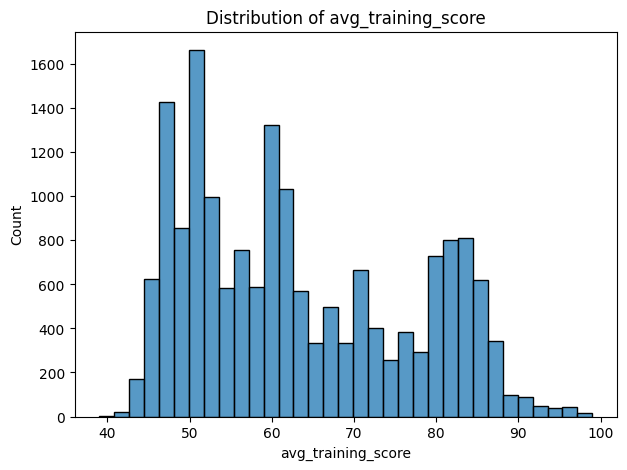

In [ ]:
# Univariate Analysis (Single Variable)
# numric columns
numric_columns = ['age','no_of_trainings','previous_year_rating','length_of_service','avg_training_score']
for col in numric_columns:
  plt.figure(figsize=(7,5))
  sns.histplot(x=col, data = hr_data)
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.title(f'Distribution of {col}')
  plt.show()

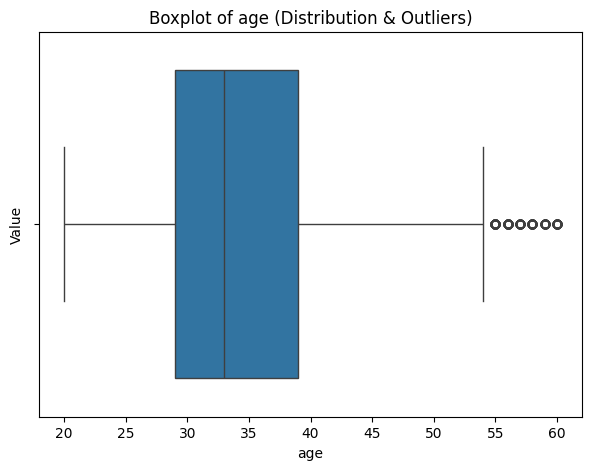

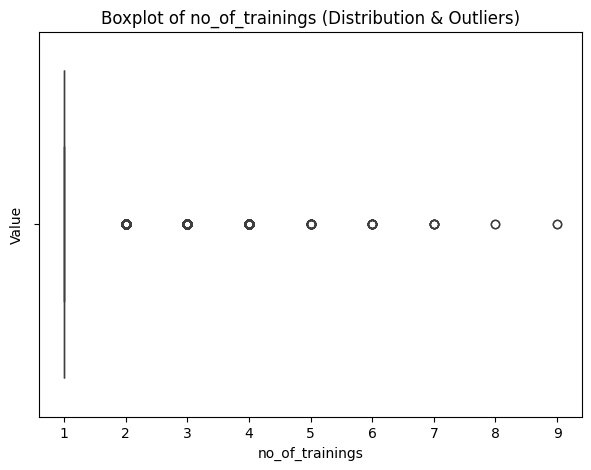

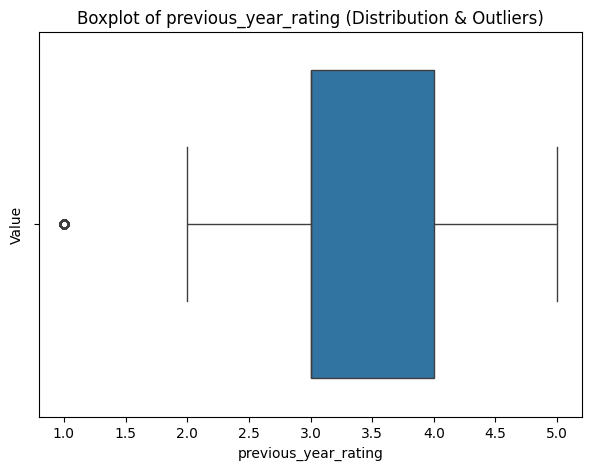

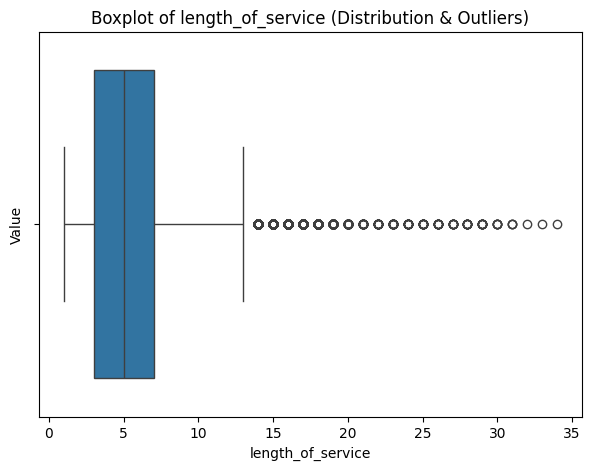

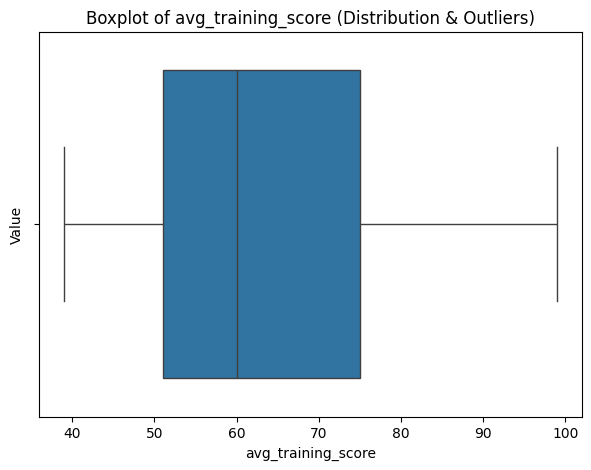

In [ ]:
numric_columns = ['age','no_of_trainings','previous_year_rating','length_of_service','avg_training_score']
for col in numric_columns:
  plt.figure(figsize=(7,5))
  sns.boxplot(x=col, data = hr_data)
  plt.xlabel(col)
  plt.ylabel('Value')
  plt.title(f'Boxplot of {col} (Distribution & Outliers)')
  plt.show()

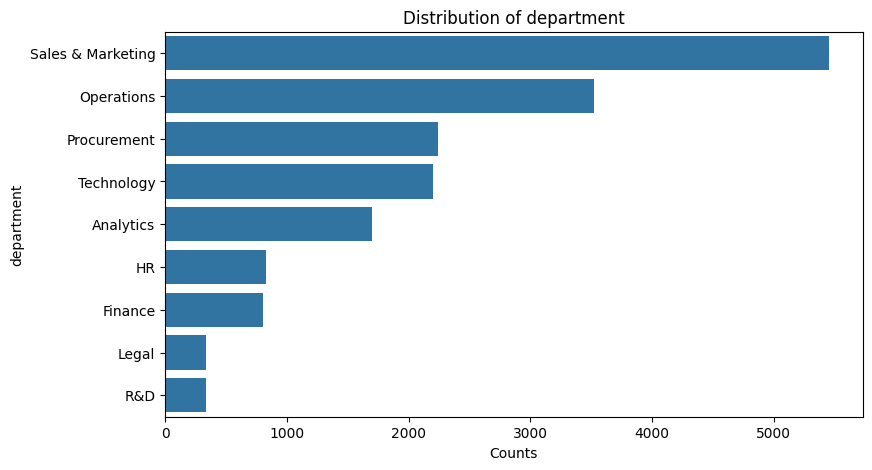

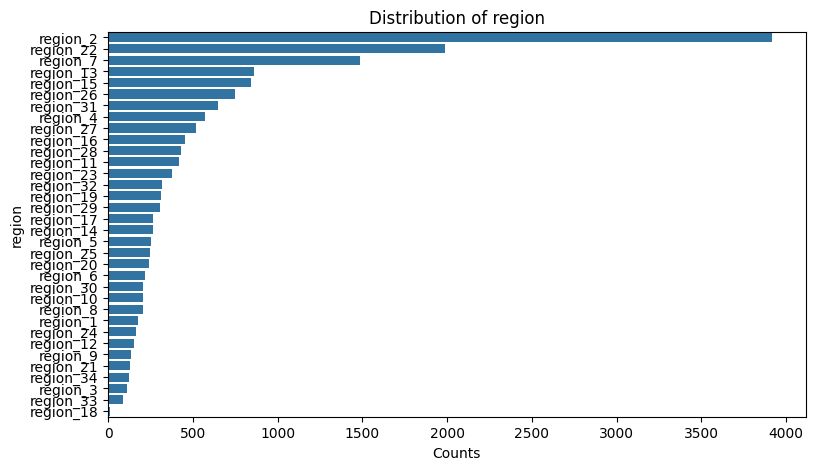

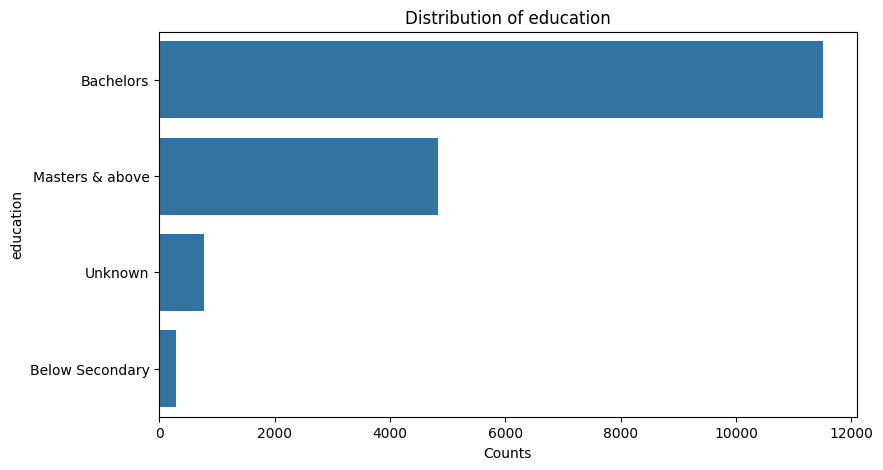

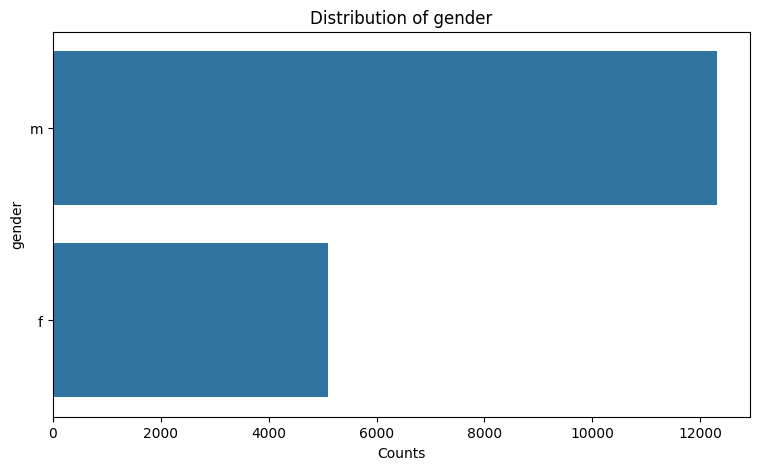

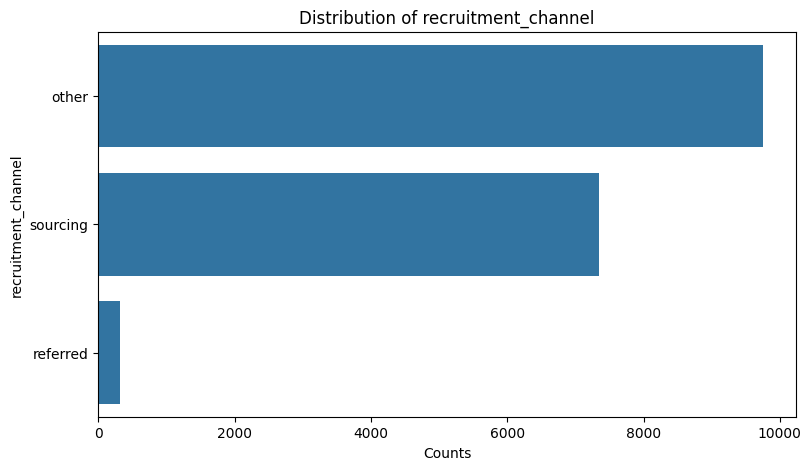

In [ ]:
# Univariate Analysis (Single Variable)
# category columns
category_columns = ['department', 'region', 'education', 'gender','recruitment_channel']
for col in category_columns:
  plt.figure(figsize=(9,5))
  order = hr_data[col].value_counts().index  # sort by frequency
  sns.countplot(y = col, data = hr_data, order = order)
  plt.xlabel('Counts')
  plt.ylabel(col)
  plt.title(f'Distribution of {col}')
  plt.show()

<Axes: >

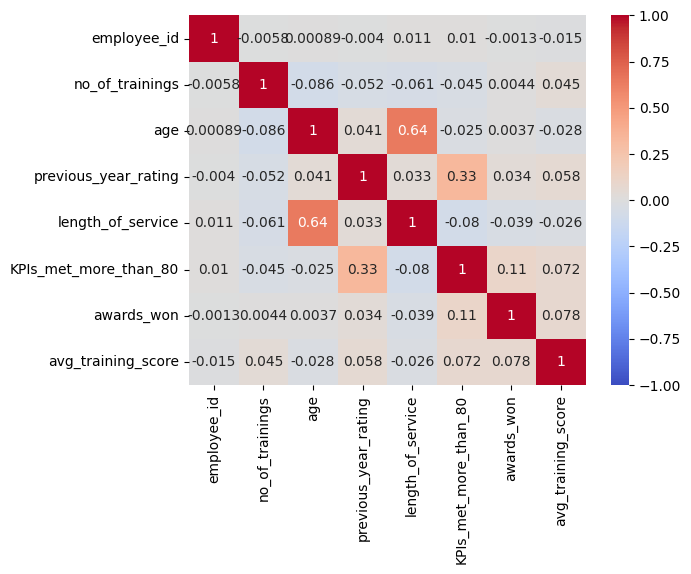

In [ ]:
# Bivariate Analysis (Relationships)
# plot correlation matrix
hr_data_corr = hr_data.corr(numeric_only=True)
sns.heatmap(data = hr_data_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# 'Age' is positively related to 'Length of Service with'  0.64
# 'Previous Year Rating' is positively related to 'Met More Than 80%' with 0.33

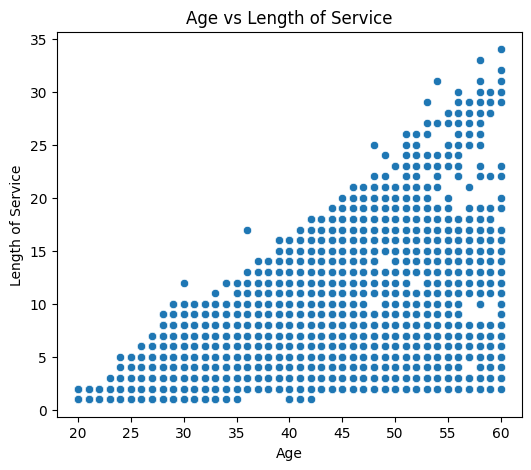

In [ ]:
# plot scatter plot between 'age' and 'length_of_service'
plt.figure(figsize=(6,5))
sns.scatterplot(x = 'age', y = 'length_of_service', data = hr_data)
plt.title('Age vs Length of Service')
plt.xlabel('Age')
plt.ylabel('Length of Service')
plt.show()

# Older employees tend to have longer service years

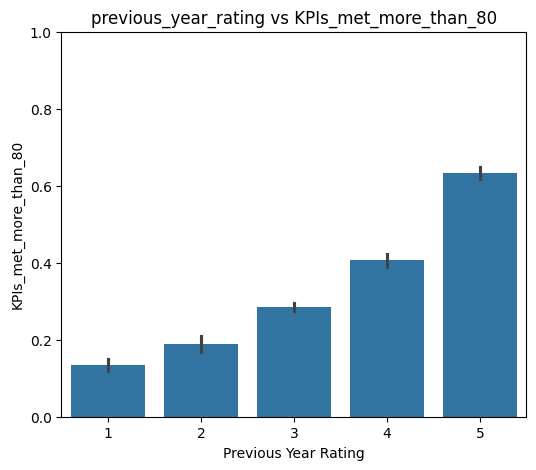

In [ ]:
# plot a bar plot between 'Previous Year Rating' and 'Met More Than 80%'

plt.figure(figsize=(6,5))
sns.barplot(x = 'previous_year_rating', y = 'KPIs_met_more_than_80', data = hr_data)
plt.title('previous_year_rating vs KPIs_met_more_than_80')
plt.xlabel('Previous Year Rating')
plt.ylabel('KPIs_met_more_than_80')
plt.ylim(0,1) # Fix y-axis limits to 0–1 since this is a probability/proportion
                # 0 = 0%, 1 = 100%
plt.show()

# Higher-rated employees are more likely to meet/exceed 80% KPI targets.

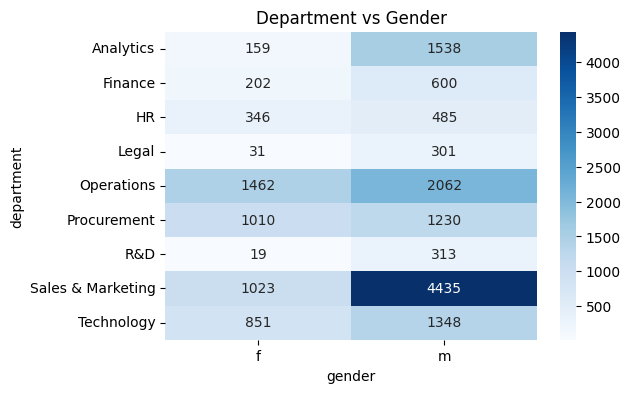

In [ ]:
# bivariate analysis
# two category columns
pd.crosstab(
    hr_data['department'],
    hr_data['gender'],
)

ct = pd.crosstab(
    hr_data['department'],
    hr_data['gender']
)

plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, cmap='Blues', fmt='d')
plt.title('Department vs Gender')
plt.show()

<Axes: xlabel='awards_won', ylabel='length_of_service'>

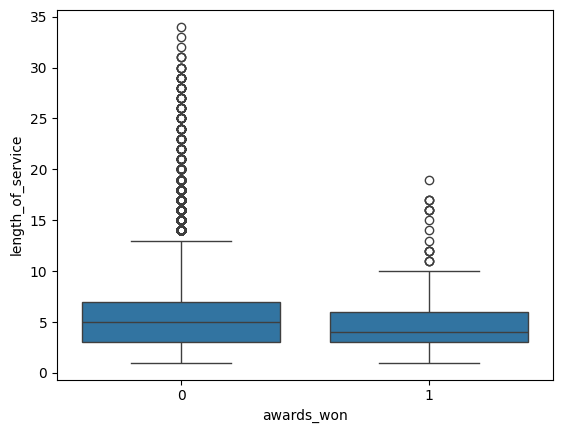

In [ ]:
# bivariate analysis
# Are experienced employees more likely to win awards?
sns.boxplot(
    data=hr_data,
    x='awards_won',
    y='length_of_service'
)

# NO

<Axes: xlabel='recruitment_channel', ylabel='avg_training_score'>

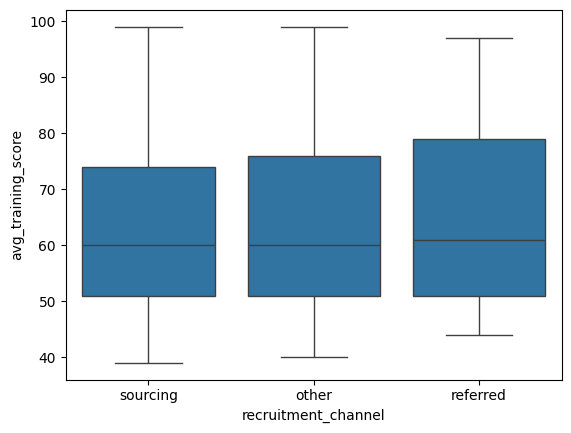

In [ ]:
# Recruitment insights
# Which recruitment channel produces strongest employees?
# plot box plot for recruitment channel and avgerage training score
sns.boxplot(
    data=hr_data,
    x='recruitment_channel',
    y='avg_training_score'
)

# referred seems to produce strong employees

In [ ]:
# HR analysis
# Employee Performance Segmentation
# find high performers based on gender
high_perf = hr_data[
    (hr_data['avg_training_score'] > 80) &
    (hr_data['KPIs_met_more_than_80'] == 1)
]
dept_counts = high_perf['gender'].value_counts()

print(dept_counts)

gender
m    945
f    227
Name: count, dtype: int64


In [ ]:
# feature engineering through binning
hr_data['experience_level'] = pd.cut(
    hr_data['length_of_service'],
    bins=[0, 3, 7, 15, 40],
    labels=['Junior', 'Mid', 'Senior', 'Veteran']
)

In [ ]:
# perform crosstab for the two categorical variables: 'experience_level' & KPIs_met_more_than_80'
cross_tab= pd.crosstab(hr_data['experience_level']
                       ,hr_data['KPIs_met_more_than_80']
)
print(cross_tab)

KPIs_met_more_than_80     0     1
experience_level                 
Junior                 3595  2246
Mid                    4529  2817
Senior                 2506  1002
Veteran                 535   185


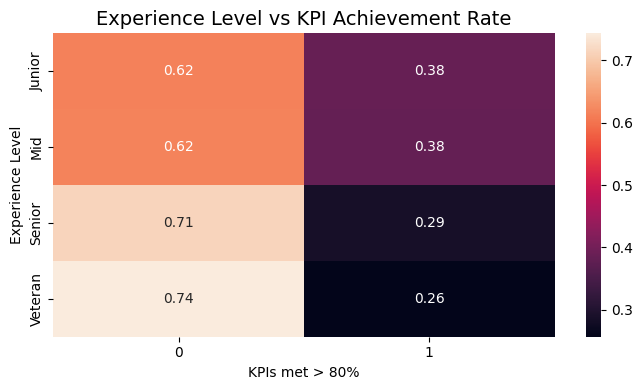

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create crosstab (better as proportions, not raw counts)
ct = pd.crosstab(
    hr_data['experience_level'],
    hr_data['KPIs_met_more_than_80'],
    normalize='index'
)

plt.figure(figsize=(7,4))

sns.heatmap(
    ct,
    annot=True,
)

plt.title('Experience Level vs KPI Achievement Rate', fontsize=14)
plt.xlabel('KPIs met > 80%')
plt.ylabel('Experience Level')

plt.tight_layout()
plt.show()